# Network-augmented model evaluation

This notebook evaluates the frozen outputs of `scripts/19_train_network_models.py`. It asks whether the six retained ownership-network predictors improve prediction beyond the selected ownership-augmented XGBoost model.

It examines:

1. validation performance across primary and network-augmented specifications;
2. matched Ridge and XGBoost comparisons;
3. aggregate and quarterly held-out test performance;
4. economic ordering of the resulting Fragility Scores; and
5. comparable residual diagnostics.

Model selection uses validation MAE only. Test outcomes are used for final evaluation and are not fed back into model choice. The notebook reads saved outputs and does not retrain any model.

## 1. Setup and output reconciliation

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error


project_root = Path.cwd().resolve()

while not (project_root / 'config' / 'paths.yaml').is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError('Could not locate the project root.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    TWO_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


paths = get_paths_config()
results_directory = paths.tables / 'modeling'
files = {
    'baseline validation': results_directory / 'baseline_validation_performance.csv',
    'network validation': results_directory / 'network_validation_performance.csv',
    'predictive benchmarks': results_directory / 'predictive_benchmark_performance.csv',
    'baseline test performance': results_directory / 'selected_baseline_test_performance.csv',
    'network test performance': results_directory / 'selected_network_test_performance.csv',
    'baseline predictions': results_directory / 'selected_baseline_test_predictions.parquet',
    'network predictions': results_directory / 'selected_network_test_predictions.parquet',
}

for description, path in files.items():
    if not path.is_file():
        raise FileNotFoundError(f'{description} not found: {path}')

baseline_validation = pd.read_csv(files['baseline validation'])
network_validation = pd.read_csv(files['network validation'])
benchmarks = pd.read_csv(files['predictive benchmarks'])
baseline_test = pd.read_csv(files['baseline test performance'])
network_test = pd.read_csv(files['network test performance'])
test_benchmark = benchmarks.loc[benchmarks['sample_split'].eq('test')].copy()
baseline_predictions = pd.read_parquet(files['baseline predictions'])
network_predictions = pd.read_parquet(files['network predictions'])

keys = ['report_period', 'information_date', 'permno']
target = 'future_max_drawdown_63d'
prediction = 'predicted_future_max_drawdown_63d'
selected_baseline = baseline_validation.loc[
    baseline_validation['selected'], 'model'
].item()
selected_network = network_validation.loc[
    network_validation['selected'], 'model'
].item()

baseline_panel = baseline_predictions.rename(
    columns={
        target: 'baseline_actual',
        prediction: 'baseline_prediction',
        'fragility_score': 'baseline_score',
    }
)
network_panel = network_predictions.rename(
    columns={
        target: 'network_actual',
        prediction: 'network_prediction',
        'fragility_score': 'network_score',
    }
)
panel = baseline_panel.merge(
    network_panel,
    on=keys,
    how='outer',
    indicator=True,
    validate='one_to_one',
)

if not panel['_merge'].eq('both').all():
    raise RuntimeError('Primary and network-augmented predictions cover different rows.')
if not np.allclose(panel['baseline_actual'], panel['network_actual']):
    raise RuntimeError('Primary and network-augmented outputs contain different targets.')
if baseline_test['model'].item() != selected_baseline:
    raise RuntimeError('Primary-model test output does not match validation selection.')
if network_test['model'].item() != selected_network:
    raise RuntimeError('Network test output does not match validation selection.')
if len(test_benchmark) != 1 or test_benchmark['model'].item() != 'naive_mean':
    raise RuntimeError('The test benchmark is missing or invalid.')

panel = panel.drop(columns='_merge').rename(columns={'baseline_actual': 'actual'})
panel = panel.drop(columns='network_actual')
set_matplotlib_style()

print(f'Selected primary model: {selected_baseline}')
print(f'Selected network model: {selected_network}')
print(f'Matched test observations: {len(panel):,}')
print(f'Test quarters: {panel["report_period"].nunique():,}')

Selected primary model: xgboost_augmented
Selected network model: xgboost_network
Matched test observations: 30,511
Test quarters: 8


## 2. Validation comparison

The selected model within each family minimizes validation MAE. The historical-mean forecast provides the no-information benchmark. Matched Ridge and XGBoost comparisons isolate the effect of adding network variables while holding the model class fixed.

,model,feature_group,observations,quarters,mae,rmse,r2,mean_quarterly_spearman,selected,family
0,xgboost_augmented,augmented,"29,716",7,0.094249,0.130522,0.475,0.750,True,Traditional
1,xgboost_network,network_augmented,"29,716",7,0.094906,0.130952,0.472,0.748,True,Network augmented
2,xgboost_market,market,"29,716",7,0.095373,0.132013,0.463,0.748,False,Traditional
3,ridge_network,network_augmented,"29,716",7,0.095573,0.133243,0.453,0.746,False,Network augmented
4,ridge_augmented,augmented,"29,716",7,0.095632,0.133361,0.452,0.746,False,Traditional
5,ridge_market,market,"29,716",7,0.095872,0.133727,0.449,0.747,False,Traditional
6,naive_mean,none,"29,716",7,0.134682,0.187086,-0.078,—,False,No information


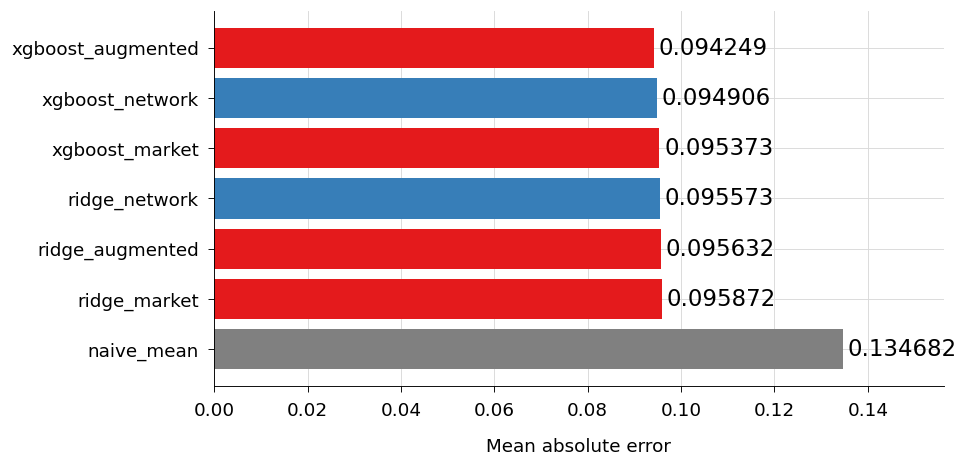

,model_class,traditional_mae,network_mae,network_minus_traditional
0,Ridge,0.095632,0.095573,-0.000059
1,XGBoost,0.094249,0.094906,+0.000656


Selected-model MAE change: +0.000656
Selected-model relative change: +0.70%


In [2]:
baseline_candidates = baseline_validation.assign(family='Traditional')
baseline_candidates.loc[
    baseline_candidates['model'].eq('naive_mean'), 'family'
] = 'No information'
network_candidates = network_validation.assign(family='Network augmented')
validation_comparison = pd.concat(
    [baseline_candidates, network_candidates],
    ignore_index=True,
).sort_values('mae').reset_index(drop=True)

display(
    validation_comparison.style.format(
        {
            'observations': '{:,}',
            'quarters': '{:,}',
            'mae': '{:.6f}',
            'rmse': '{:.6f}',
            'r2': '{:.3f}',
            'mean_quarterly_spearman': '{:.3f}',
        },
        na_rep='—',
    )
)

plot_data = validation_comparison.copy()
family_colors = {
    'Traditional': COLOR_PALETTE[1],
    'Network augmented': COLOR_PALETTE[0],
    'No information': 'gray',
}
colors = plot_data['family'].map(family_colors)
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
bars = axis.barh(plot_data['model'], plot_data['mae'], color=colors)
axis.invert_yaxis()
axis.bar_label(bars, fmt='%.6f', padding=3)
axis.set_xlabel('Mean absolute error')
axis.set_ylabel('')
axis.set_xlim(0, plot_data['mae'].max() * 1.16)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_04_validation_mae_across_specifications.pdf")
plt.show()

matched_validation = pd.DataFrame(
    [
        {
            'model_class': 'Ridge',
            'traditional_mae': baseline_validation.loc[
                baseline_validation['model'].eq('ridge_augmented'), 'mae'
            ].item(),
            'network_mae': network_validation.loc[
                network_validation['model'].eq('ridge_network'), 'mae'
            ].item(),
        },
        {
            'model_class': 'XGBoost',
            'traditional_mae': baseline_validation.loc[
                baseline_validation['model'].eq('xgboost_augmented'), 'mae'
            ].item(),
            'network_mae': network_validation.loc[
                network_validation['model'].eq('xgboost_network'), 'mae'
            ].item(),
        },
    ]
)
matched_validation['network_minus_traditional'] = (
    matched_validation['network_mae'] - matched_validation['traditional_mae']
)
display(
    matched_validation.style.format(
        {
            'traditional_mae': '{:.6f}',
            'network_mae': '{:.6f}',
            'network_minus_traditional': '{:+.6f}',
        }
    )
)

baseline_validation_mae = baseline_validation.loc[
    baseline_validation['selected'], 'mae'
].item()
network_validation_mae = network_validation.loc[
    network_validation['selected'], 'mae'
].item()
validation_mae_change = network_validation_mae - baseline_validation_mae
print(f'Selected-model MAE change: {validation_mae_change:+.6f}')
print(
    'Selected-model relative change: '
    f'{validation_mae_change / baseline_validation_mae:+.2%}'
)

## 3. Aggregate held-out test comparison

The primary and network-augmented models cover the same test observations. Lower MAE and RMSE, and higher R-squared and quarterly Spearman correlation, indicate better performance. The historical-mean forecast benchmarks prediction magnitude; zero correlation is the random-ordering reference.

In [3]:
test_comparison = pd.concat(
    [
        test_benchmark.assign(
            model_family='No information',
            mean_quarterly_spearman=np.nan,
        ),
        baseline_test.assign(model_family='Primary XGBoost'),
        network_test.assign(model_family='Network augmented'),
    ],
    ignore_index=True,
)
display(
    test_comparison[
        [
            'model_family',
            'model',
            'observations',
            'quarters',
            'mae',
            'rmse',
            'r2',
            'mean_quarterly_spearman',
        ]
    ].style.format(
        {
            'observations': '{:,}',
            'quarters': '{:,}',
            'mae': '{:.4f}',
            'rmse': '{:.4f}',
            'r2': '{:.3f}',
            'mean_quarterly_spearman': '{:.3f}',
        }
    )
)

baseline_test_mae = baseline_test['mae'].item()
network_test_mae = network_test['mae'].item()
test_mae_change = network_test_mae - baseline_test_mae
prediction_rank_correlation = panel['baseline_prediction'].corr(
    panel['network_prediction'],
    method='spearman',
)

print(f'Network minus primary XGBoost test MAE: {test_mae_change:+.6f}')
print(f'Relative test MAE change: {test_mae_change / baseline_test_mae:+.2%}')
print(f'Prediction-rank correlation: {prediction_rank_correlation:.3f}')

,model_family,model,observations,quarters,mae,rmse,r2,mean_quarterly_spearman
0,No information,naive_mean,"30,511",8,0.1302,0.1819,-0.053,nan
1,Primary XGBoost,xgboost_augmented,"30,511",8,0.0904,0.1249,0.504,0.739
2,Network augmented,xgboost_network,"30,511",8,0.0900,0.1245,0.507,0.738


Network minus primary XGBoost test MAE: -0.000415
Relative test MAE change: -0.46%
Prediction-rank correlation: 0.996


## 4. Performance differences by test quarter

The plots report network minus primary XGBoost performance. Negative MAE differences and positive Spearman differences favor the network model; the zero line represents equal performance.

,report_period,observations,baseline_mae,network_mae,mae_difference,baseline_spearman,network_spearman,spearman_difference
0,2024-03-31 00:00:00,"4,005",0.0821,0.0822,+0.0000,0.803,0.801,-0.002
1,2024-06-30 00:00:00,"3,946",0.0864,0.0866,+0.0002,0.765,0.763,-0.002
2,2024-09-30 00:00:00,"3,869",0.0827,0.0829,+0.0002,0.730,0.729,-0.002
3,2024-12-31 00:00:00,"3,819",0.1191,0.1185,-0.0006,0.729,0.727,-0.002
4,2025-03-31 00:00:00,"3,767",0.0923,0.0895,-0.0028,0.724,0.727,+0.003
5,2025-06-30 00:00:00,"3,733",0.0822,0.0818,-0.0004,0.719,0.719,+0.001
6,2025-09-30 00:00:00,"3,706",0.0933,0.0930,-0.0003,0.747,0.746,-0.001
7,2025-12-31 00:00:00,"3,666",0.0855,0.0858,+0.0003,0.695,0.692,-0.003


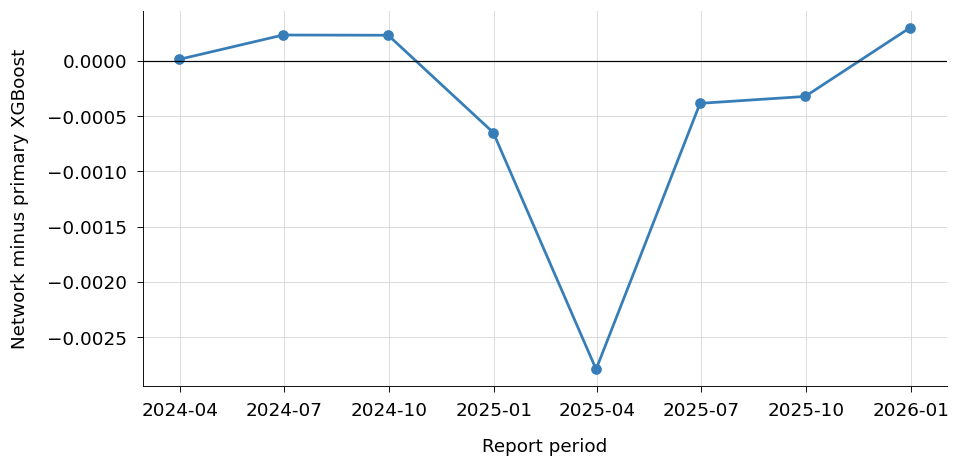

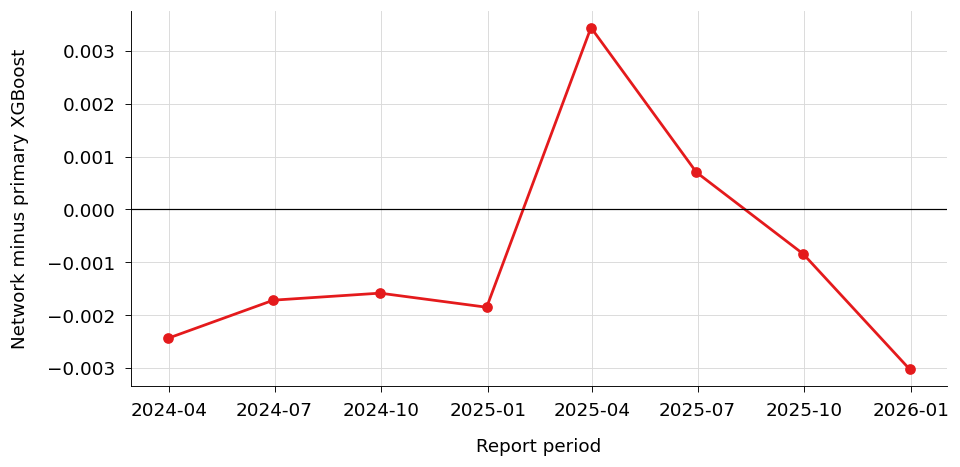

Quarters with lower network MAE: 4 / 8
Quarters with higher network Spearman: 2 / 8


In [4]:
quarterly_rows = []
for report_period, quarter in panel.groupby('report_period', sort=True):
    baseline_mae = mean_absolute_error(
        quarter['actual'], quarter['baseline_prediction']
    )
    network_mae = mean_absolute_error(
        quarter['actual'], quarter['network_prediction']
    )
    baseline_spearman = quarter['actual'].corr(
        quarter['baseline_prediction'], method='spearman'
    )
    network_spearman = quarter['actual'].corr(
        quarter['network_prediction'], method='spearman'
    )
    quarterly_rows.append(
        {
            'report_period': report_period,
            'observations': len(quarter),
            'baseline_mae': baseline_mae,
            'network_mae': network_mae,
            'mae_difference': network_mae - baseline_mae,
            'baseline_spearman': baseline_spearman,
            'network_spearman': network_spearman,
            'spearman_difference': network_spearman - baseline_spearman,
        }
    )
quarterly_performance = pd.DataFrame(quarterly_rows)

display(
    quarterly_performance.style.format(
        {
            'observations': '{:,}',
            'baseline_mae': '{:.4f}',
            'network_mae': '{:.4f}',
            'mae_difference': '{:+.4f}',
            'baseline_spearman': '{:.3f}',
            'network_spearman': '{:.3f}',
            'spearman_difference': '{:+.3f}',
        }
    )
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    quarterly_performance['report_period'],
    quarterly_performance['mae_difference'],
    marker='o',
    color=COLOR_PALETTE[0],
)
axis.axhline(0, color='black', linewidth=0.8)
axis.set_xlabel('Report period')
axis.set_ylabel('Network minus primary XGBoost')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_04_quarterly_mae_difference.pdf')
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    quarterly_performance['report_period'],
    quarterly_performance['spearman_difference'],
    marker='o',
    color=COLOR_PALETTE[1],
)
axis.axhline(0, color='black', linewidth=0.8)
axis.set_xlabel('Report period')
axis.set_ylabel('Network minus primary XGBoost')

apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_04_quarterly_spearman_difference.pdf')
plt.show()

network_mae_wins = quarterly_performance['mae_difference'].lt(0).sum()
network_spearman_wins = quarterly_performance['spearman_difference'].gt(0).sum()
print(f'Quarters with lower network MAE: {network_mae_wins} / {len(quarterly_performance)}')
print(
    'Quarters with higher network Spearman: '
    f'{network_spearman_wins} / {len(quarterly_performance)}'
)

## 5. Fragility Score ordering

Both scores are within-quarter percentile ranks. A useful score should place subsequently larger realized drawdowns in higher deciles.

model,Network augmented,Primary XGBoost
fragility_decile,,
1,10.62%,10.49%
2,13.10%,13.10%
3,14.54%,14.60%
4,17.14%,17.17%
5,19.75%,19.72%
6,23.05%,23.18%
7,26.94%,26.98%
8,32.32%,32.17%
9,38.97%,39.13%


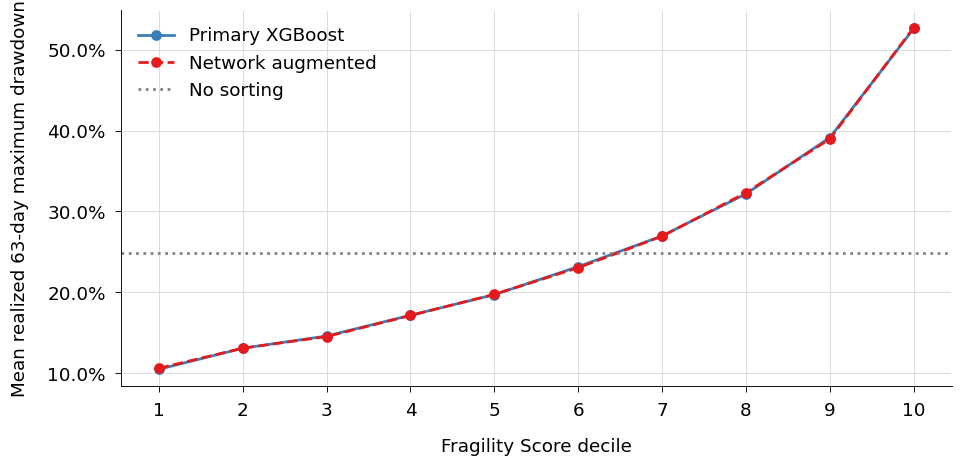

,model,decile_10_minus_1,increasing_steps
0,Primary XGBoost,42.12%,9
1,Network augmented,42.10%,9


In [5]:
for model in ['baseline', 'network']:
    panel[f'{model}_decile'] = np.minimum(
        np.floor(panel[f'{model}_score'] / 10).astype(int) + 1,
        10,
    )

decile_rows = []
for model, label in [
    ('baseline', 'Primary XGBoost'),
    ('network', 'Network augmented'),
]:
    summary = (
        panel.groupby(f'{model}_decile', as_index=False)
        .agg(
            observations=('actual', 'size'),
            mean_realized_drawdown=('actual', 'mean'),
        )
        .rename(columns={f'{model}_decile': 'fragility_decile'})
    )
    summary['model'] = label
    decile_rows.append(summary)
decile_summary = pd.concat(decile_rows, ignore_index=True)

display(
    decile_summary.pivot(
        index='fragility_decile',
        columns='model',
        values='mean_realized_drawdown',
    ).style.format('{:.2%}')
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for label, group in decile_summary.groupby('model', sort=False):
    color = (
        COLOR_PALETTE[0]
        if label == 'Primary XGBoost'
        else COLOR_PALETTE[1]
    )
    linestyle = (
        "-"
        if label == 'Primary XGBoost'
        else '--'
    )
    axis.plot(
        group['fragility_decile'],
        group['mean_realized_drawdown'],
        marker='o',
        color=color,
        linestyle=linestyle,
        label=label,
    )
axis.axhline(
    panel['actual'].mean(),
    color='gray',
    linestyle=':',
    label='No sorting',
)
axis.set_xlabel('Fragility Score decile')
axis.set_ylabel('Mean realized 63-day maximum drawdown')
axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_04_fragility_score_ordering.pdf")
plt.show()

ordering_rows = []
for label, group in decile_summary.groupby('model', sort=False):
    values = group.set_index('fragility_decile')['mean_realized_drawdown']
    ordering_rows.append(
        {
            'model': label,
            'decile_10_minus_1': values.loc[10] - values.loc[1],
            'increasing_steps': int(values.diff().dropna().gt(0).sum()),
        }
    )
ordering_summary = pd.DataFrame(ordering_rows)
display(
    ordering_summary.style.format({'decile_10_minus_1': '{:.2%}'})
)

## 6. Error-pattern comparison

The same descriptive residual diagnostics are calculated for both models. Lower absolute error is better; a positive residual means underprediction. These test diagnostics compare error behavior and do not affect model selection.

,model,mean_residual,predicted_d10_mae,realized_d10_mae,realized_d10_mean_residual,lag_one_residual_correlation
0,Primary XGBoost,+1.08%,16.18%,23.62%,+23.33%,-0.029
1,Network augmented,+1.15%,16.09%,23.38%,+22.98%,-0.028


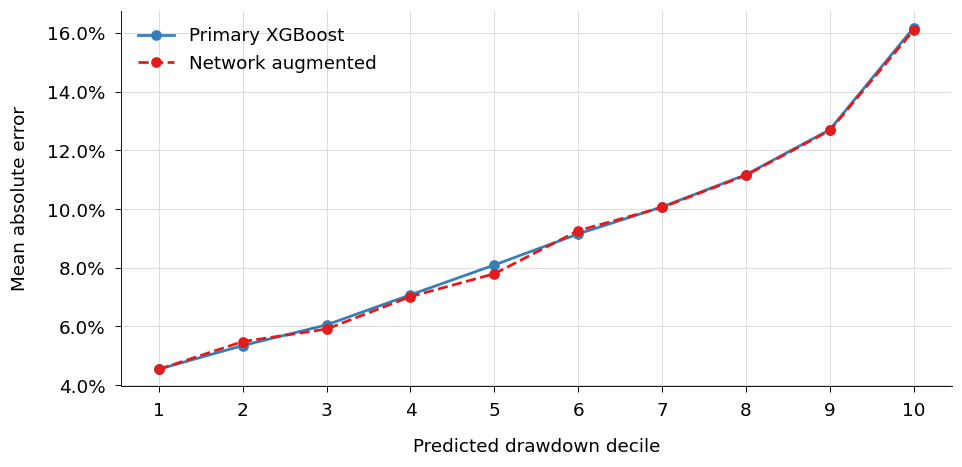

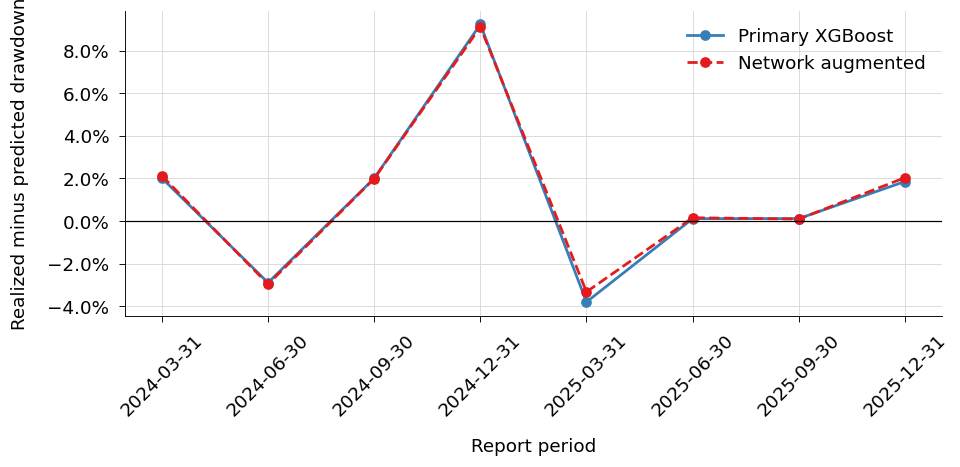

In [6]:
model_predictions = {
    'Primary XGBoost': 'baseline_prediction',
    'Network augmented': 'network_prediction',
}
panel['realized_decile'] = pd.qcut(
    panel['actual'].rank(method='first'),
    10,
    labels=False,
) + 1
report_dates = pd.to_datetime(panel['report_period'])
panel['quarter_number'] = report_dates.dt.year * 4 + report_dates.dt.quarter
summary_rows = []
decile_rows = []
quarter_rows = []

for label, prediction_column in model_predictions.items():
    residual = panel['actual'] - panel[prediction_column]
    absolute_error = residual.abs()
    prediction_decile = pd.qcut(
        panel[prediction_column].rank(method='first'),
        10,
        labels=False,
    ) + 1
    severe = panel['realized_decile'].eq(10)
    ordered = panel[['permno', 'quarter_number']].copy()
    ordered['residual'] = residual
    ordered = ordered.sort_values(['permno', 'quarter_number'])
    ordered['previous_residual'] = ordered.groupby('permno')['residual'].shift()
    ordered['previous_quarter'] = ordered.groupby('permno')['quarter_number'].shift()
    consecutive = ordered.loc[
        ordered['quarter_number'].eq(ordered['previous_quarter'] + 1)
    ]
    summary_rows.append(
        {
            'model': label,
            'mean_residual': residual.mean(),
            'predicted_d10_mae': absolute_error[prediction_decile.eq(10)].mean(),
            'realized_d10_mae': absolute_error[severe].mean(),
            'realized_d10_mean_residual': residual[severe].mean(),
            'lag_one_residual_correlation': consecutive['residual'].corr(
                consecutive['previous_residual']
            ),
        }
    )
    for decile in range(1, 11):
        decile_rows.append(
            {
                'model': label,
                'prediction_decile': decile,
                'mae': absolute_error[prediction_decile.eq(decile)].mean(),
            }
        )
    for report_period in sorted(panel['report_period'].unique()):
        quarter = panel['report_period'].eq(report_period)
        quarter_rows.append(
            {
                'model': label,
                'report_period': report_period,
                'mean_residual': residual[quarter].mean(),
            }
        )

error_summary = pd.DataFrame(summary_rows)
error_by_prediction_decile = pd.DataFrame(decile_rows)
quarterly_bias = pd.DataFrame(quarter_rows)
display(
    error_summary.style.format(
        {
            'mean_residual': '{:+.2%}',
            'predicted_d10_mae': '{:.2%}',
            'realized_d10_mae': '{:.2%}',
            'realized_d10_mean_residual': '{:+.2%}',
            'lag_one_residual_correlation': '{:.3f}',
        }
    )
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for index, (label, group) in enumerate(
    error_by_prediction_decile.groupby('model', sort=False)
):
    axis.plot(
        group['prediction_decile'],
        group['mae'],
        marker='o',
        color=COLOR_PALETTE[index],
        linestyle='--' if label == 'Network augmented' else '-',
        label=label,
    )
axis.set_xlabel('Predicted drawdown decile')
axis.set_ylabel('Mean absolute error')
axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_04_error_by_prediction_decile.pdf')
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for index, (label, group) in enumerate(
    quarterly_bias.groupby('model', sort=False)
):
    axis.plot(
        group['report_period'].astype(str),
        group['mean_residual'],
        marker='o',
        color=COLOR_PALETTE[index],
        linestyle='--' if label == 'Network augmented' else '-',
        label=label,
    )
axis.axhline(0, color='black', linewidth=0.8)
axis.set_xlabel('Report period')
axis.set_ylabel('Realized minus predicted drawdown')
axis.tick_params(axis='x', rotation=45)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_04_mean_residual_by_test_quarter.pdf')
plt.show()

## 7. Interpretation

- **Engineered network features do not improve the validation selection criterion.** The selected network candidate, `xgboost_network`, has validation MAE of 0.094906, compared with 0.094249 for the selected ownership-augmented model. The difference is 0.000656, or 0.70%, in favor of the simpler model.
- **Matched comparisons are mixed.** Adding the six retained network features changes Ridge validation MAE from 0.095632 to 0.095573, a negligible improvement, but changes XGBoost validation MAE from 0.094249 to 0.094906, a deterioration. There is therefore no consistent incremental gain across model classes.
- **Held-out differences are very small and do not reverse the validation decision.** The network model has slightly lower test MAE (0.0900 versus 0.0904), slightly lower RMSE, and slightly higher R-squared, but marginally lower mean quarterly Spearman correlation (0.7381 versus 0.7390). It wins on MAE in four of eight quarters and on rank correlation in two.
- **The predictions are nearly identical.** Their test prediction ranks correlate 0.996, indicating that engineered network variables make only minor changes to the ordering already produced by market and ownership predictors.
- **Both models remain clearly predictive.** Each substantially outperforms the historical-mean benchmark, and both Fragility Scores retain strong realized-drawdown ordering. The issue is incremental value, not whether either model predicts downside risk.

The engineered network features provide mixed and economically negligible differences rather than a reliable validation improvement. The augmented XGBoost model therefore remains the primary tabular specification.